# 🔍 Unsupervised Learning & Anomaly Detection
## COMPAS Recidivism Dataset

### What we will cover:
1. **K-Means Clustering** — hard clusters
2. **Hierarchical Clustering** — tree based segments
3. **PCA** — 2D visualization
4. **GMM** — soft clusters with probabilities
5. **Anomaly Detection** — Z-score, IsolationForest, LOF

In [1]:
# Cell 1 - Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy import stats

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Cell 2 - Load and prepare data
df = pd.read_csv(r'C:\Users\fo2225\criminal_justice_app\compas.csv')
df = df[['age', 'sex', 'race', 'priors_count', 'c_charge_degree', 'two_year_recid']].dropna()

# Encode categorical variables
df['sex'] = df['sex'].map({'Male': 1, 'Female': 0})
df['c_charge_degree'] = df['c_charge_degree'].map({'F': 1, 'M': 0})

# One-hot encode race
df = pd.get_dummies(df, columns=['race'])

print("Columns after one-hot encoding:")
print(df.columns.tolist())

# Features only — no target variable for unsupervised learning
X = df.drop('two_year_recid', axis=1)

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nDataset shape:", X.shape)
print("Scaling done!")

Columns after one-hot encoding:
['age', 'sex', 'priors_count', 'c_charge_degree', 'two_year_recid', 'race_African-American', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Native American', 'race_Other']

Dataset shape: (7214, 10)
Scaling done!


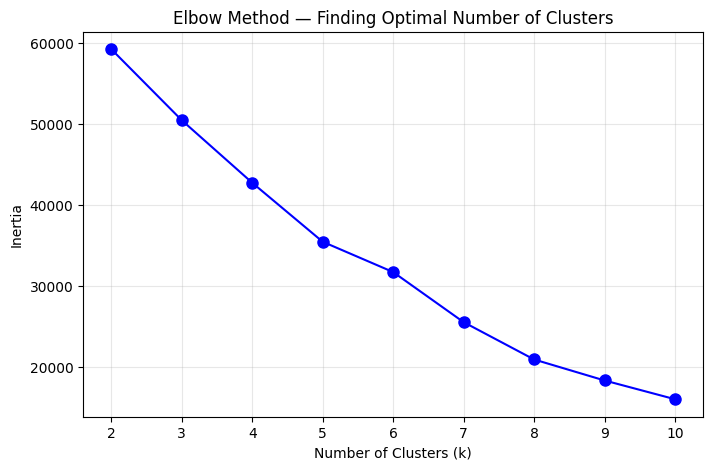

In [3]:
# Cell 3 - K-Means: Elbow Method
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, 'bo-', markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Finding Optimal Number of Clusters')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.show()

Variance captured by PCA: 31.7%


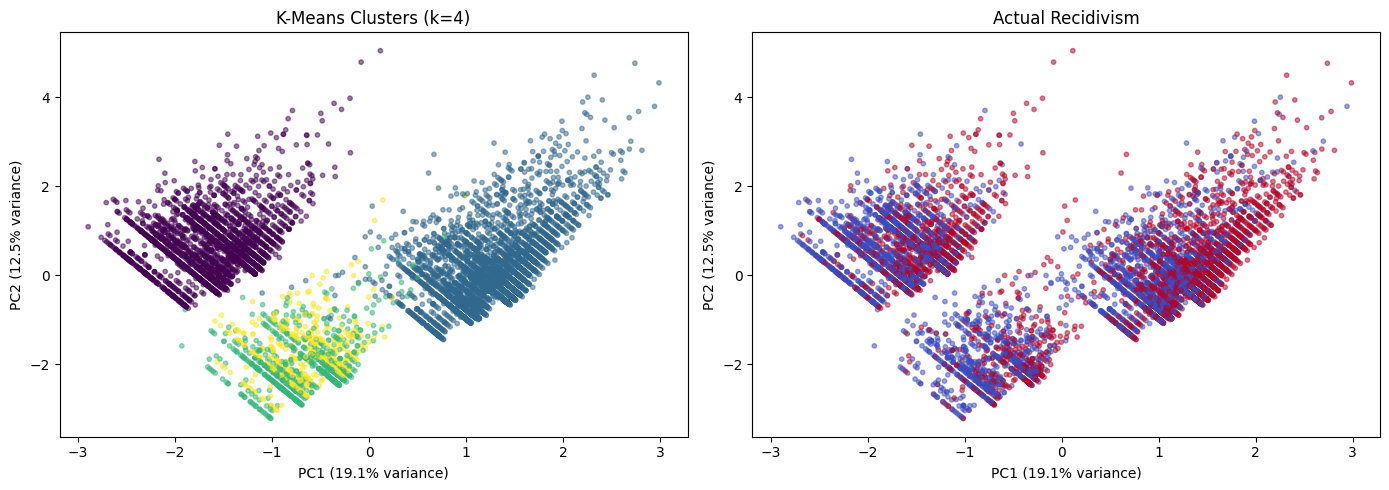

In [4]:
# Cell 4 - K-Means Clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance captured by PCA: {pca.explained_variance_ratio_.sum():.1%}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K-Means clusters
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], 
                c=clusters, cmap='viridis', alpha=0.5, s=10)
axes[0].set_title('K-Means Clusters (k=4)')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')

# Actual recidivism
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], 
                c=df['two_year_recid'], cmap='coolwarm', alpha=0.5, s=10)
axes[1].set_title('Actual Recidivism')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')

plt.tight_layout()
plt.show()

## 🔵 K-Means Clustering Results

### PCA captured 31.6% of total variance
With one-hot encoded race (10 features vs 5 before), the data is more 
complex and harder to represent in 2D. This is normal.

### What we see:
- K-Means found 4 distinct groups (left chart)
- The clusters separate reasonably well along PC1 (horizontal)
- Actual recidivism (right chart) shows red/blue mixed throughout
- This confirms natural groupings are NOT purely driven by recidivism

### Key observation:
The striped pattern in the data is caused by the one-hot encoded 
race columns creating discrete groupings.

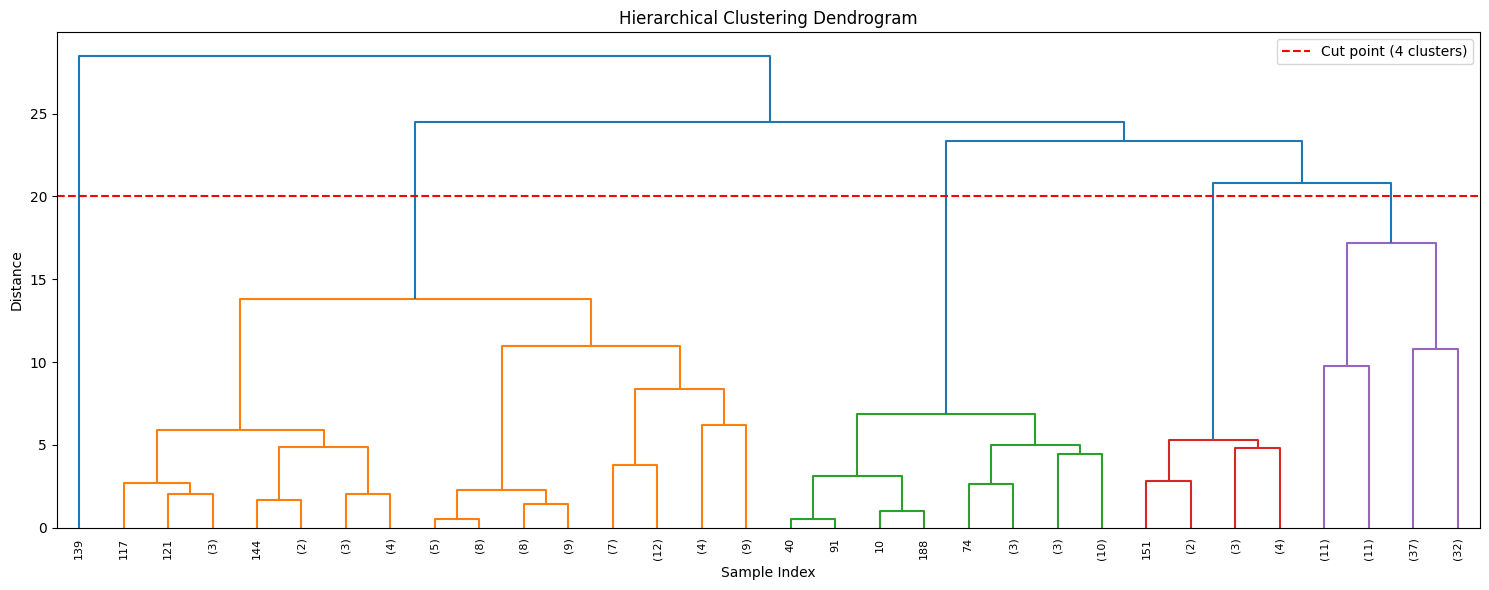

In [5]:
# Cell 5 - Hierarchical Clustering Dendrogram
# Use a sample of 200 points — full dataset is too slow for dendrogram
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), 200, replace=False)
X_sample = X_scaled[sample_idx]

# Build linkage matrix
linked = linkage(X_sample, method='ward')

# Plot dendrogram
plt.figure(figsize=(15, 6))
dendrogram(linked, 
           truncate_mode='level',
           p=5,
           leaf_rotation=90,
           leaf_font_size=8,
           color_threshold=20)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.axhline(y=20, color='red', linestyle='--', label='Cut point (4 clusters)')
plt.legend()
plt.tight_layout()
plt.show()

## 🌳 Hierarchical Clustering — Dendrogram

### How to read this chart:
- Each **leaf** at the bottom is one data point
- **Lines merging together** = two clusters being combined
- **Height of the merge** = how different those clusters were
- The **red dashed line** is our cut point — where we decide to stop merging

### What we see:
- Cutting at height 20 gives us **4 clusters** — matching our K-Means result
- The **left side** (orange) merges at lower heights — these points are very similar to each other
- The **right side** merges at higher heights — more diverse group
- The two **main branches** at the top merge very late (height ~28) meaning they are quite different from each other

### K-Means vs Hierarchical:
| | K-Means | Hierarchical |
|---|---|---|
| You specify | Number of clusters | Cut point |
| Speed | Fast | Slow on large data |
| Result | Hard assignments | Tree structure |
| Best for | Large datasets | Understanding relationships |

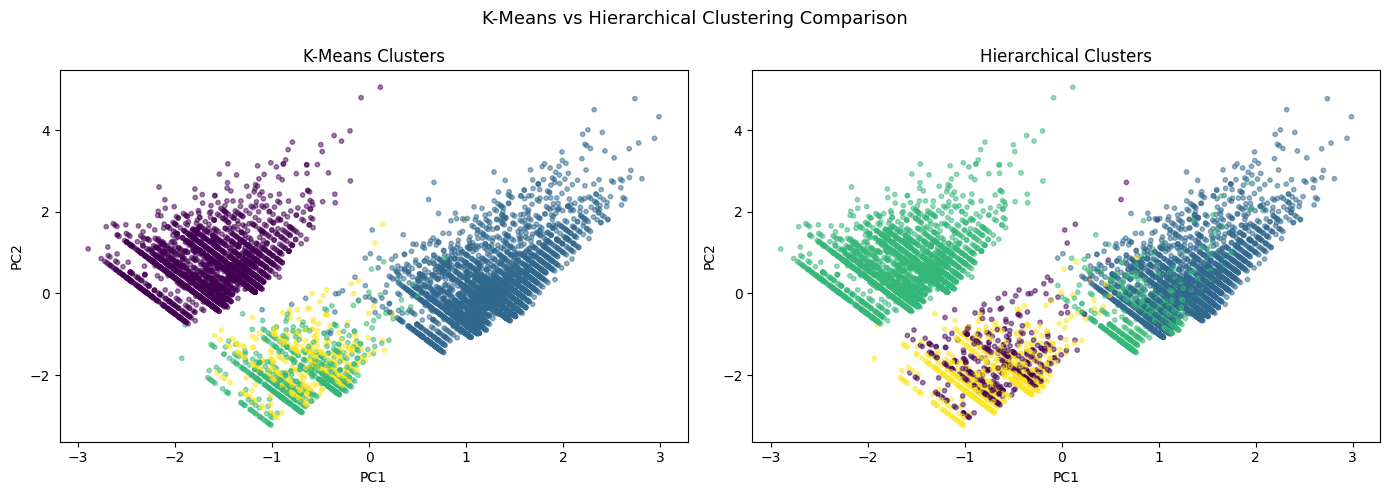

In [6]:
# Cell 6 - Apply Hierarchical Clustering
hierarchical = AgglomerativeClustering(n_clusters=4)
hier_clusters = hierarchical.fit_predict(X_scaled)

# Compare with K-Means in PCA space
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                c=clusters, cmap='viridis', alpha=0.5, s=10)
axes[0].set_title('K-Means Clusters')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                c=hier_clusters, cmap='viridis', alpha=0.5, s=10)
axes[1].set_title('Hierarchical Clusters')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.suptitle('K-Means vs Hierarchical Clustering Comparison', fontsize=13)
plt.tight_layout()
plt.show()

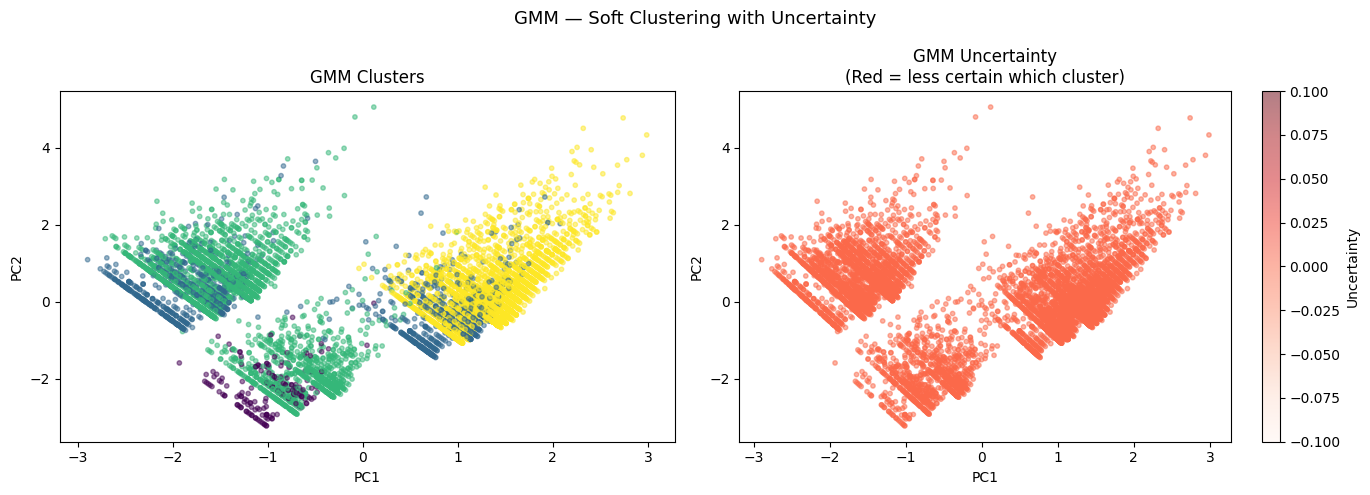

Example — first 5 cases, probability of belonging to each cluster:
   Cluster 0  Cluster 1  Cluster 2  Cluster 3
0        0.0        0.0        1.0        0.0
1        0.0        0.0        0.0        1.0
2        0.0        0.0        0.0        1.0
3        0.0        0.0        0.0        1.0
4        0.0        0.0        1.0        0.0


In [7]:
# Cell 7 - GMM (Gaussian Mixture Models)
gmm = GaussianMixture(n_components=4, random_state=42)
gmm.fit(X_scaled)
gmm_clusters = gmm.predict(X_scaled)
gmm_probs = gmm.predict_proba(X_scaled)

# Plot clusters
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GMM clusters
axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                c=gmm_clusters, cmap='viridis', alpha=0.5, s=10)
axes[0].set_title('GMM Clusters')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# GMM uncertainty — how confident is the model?
uncertainty = 1 - gmm_probs.max(axis=1)
scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                          c=uncertainty, cmap='Reds', alpha=0.5, s=10)
plt.colorbar(scatter, ax=axes[1], label='Uncertainty')
axes[1].set_title('GMM Uncertainty\n(Red = less certain which cluster)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.suptitle('GMM — Soft Clustering with Uncertainty', fontsize=13)
plt.tight_layout()
plt.show()

# Show probability example
print("Example — first 5 cases, probability of belonging to each cluster:")
prob_df = pd.DataFrame(gmm_probs[:5], 
                       columns=[f'Cluster {i}' for i in range(4)])
prob_df = prob_df.round(3)
print(prob_df)

## 🎯 GMM — Gaussian Mixture Models (Soft Clustering)

### What makes GMM different from K-Means?
K-Means gives each point a HARD assignment — you belong to cluster 3, period.
GMM gives each point a SOFT assignment — you belong to cluster 3 
with 85% probability, cluster 1 with 10%, cluster 2 with 5%.

### Left chart — GMM Clusters:
Similar structure to K-Means but with softer, more flexible boundaries.
GMM assumes each cluster follows a Gaussian (bell curve) distribution.

### Right chart — Uncertainty:
- **Red dots** = model is uncertain which cluster this point belongs to
- **Pink/white dots** = model is very confident
- The uncertainty is highest at the **boundaries between clusters** — exactly where you'd expect!

### Probability table — first 5 cases:
Each row shows the probability of belonging to each cluster.
Most cases show 1.0 for one cluster and 0.0 for others — 
meaning GMM is very confident for most points.

### When to use GMM vs K-Means:
| | K-Means | GMM |
|---|---|---|
| Cluster shape | Spherical only | Any shape |
| Assignment | Hard (0 or 1) | Soft (probabilities) |
| Speed | Faster | Slower |
| Best for | Clear separated clusters | Overlapping clusters |

Total cases: 7214
Anomalies detected by Z-score: 1245
Anomaly rate: 17.3%


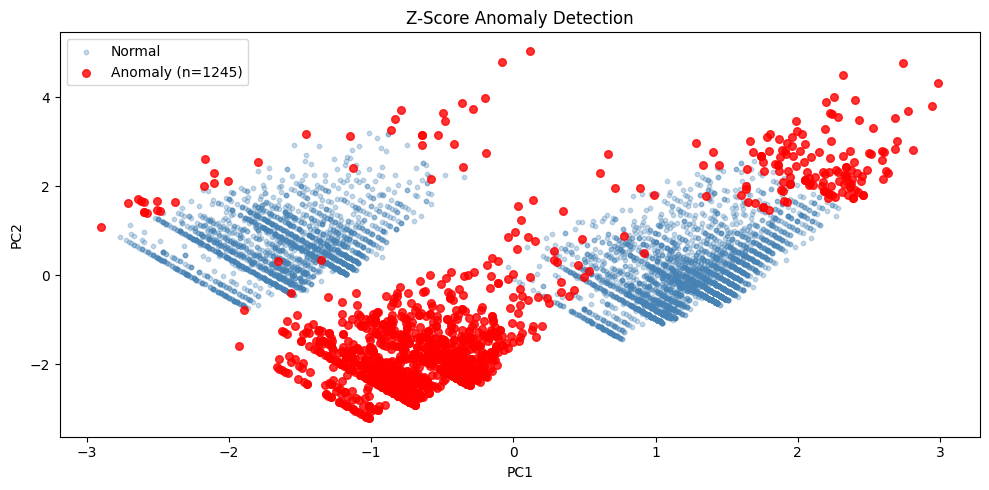

In [8]:
# Cell 8 - Anomaly Detection: Z-Score
from scipy import stats

# Calculate Z-scores for each feature
z_scores = np.abs(stats.zscore(X_scaled))

# Flag as anomaly if ANY feature has z-score > 3
z_anomalies = (z_scores > 3).any(axis=1)

print(f"Total cases: {len(X)}")
print(f"Anomalies detected by Z-score: {z_anomalies.sum()}")
print(f"Anomaly rate: {z_anomalies.mean():.1%}")

# Visualize
plt.figure(figsize=(10, 5))
plt.scatter(X_pca[~z_anomalies, 0], X_pca[~z_anomalies, 1],
            c='steelblue', alpha=0.3, s=10, label='Normal')
plt.scatter(X_pca[z_anomalies, 0], X_pca[z_anomalies, 1],
            c='red', alpha=0.8, s=30, label=f'Anomaly (n={z_anomalies.sum()})')
plt.title('Z-Score Anomaly Detection')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.show()

Anomalies detected by Isolation Forest: 360
Anomaly rate: 5.0%


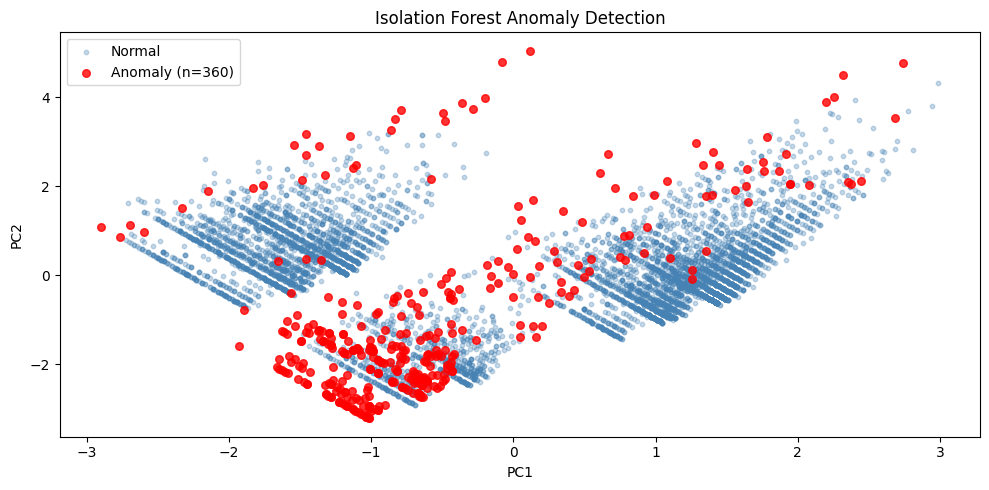

In [9]:
# Cell 9 - Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)
iso_predictions = iso_forest.fit_predict(X_scaled)

# Isolation Forest returns -1 for anomalies, 1 for normal
iso_anomalies = iso_predictions == -1

print(f"Anomalies detected by Isolation Forest: {iso_anomalies.sum()}")
print(f"Anomaly rate: {iso_anomalies.mean():.1%}")

# Visualize
plt.figure(figsize=(10, 5))
plt.scatter(X_pca[~iso_anomalies, 0], X_pca[~iso_anomalies, 1],
            c='steelblue', alpha=0.3, s=10, label='Normal')
plt.scatter(X_pca[iso_anomalies, 0], X_pca[iso_anomalies, 1],
            c='red', alpha=0.8, s=30, label=f'Anomaly (n={iso_anomalies.sum()})')
plt.title('Isolation Forest Anomaly Detection')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\fo2225\AppData\Local\anaconda3-2025-12\envs\criminal_justice\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


Anomalies detected by LOF: 361
Anomaly rate: 5.0%


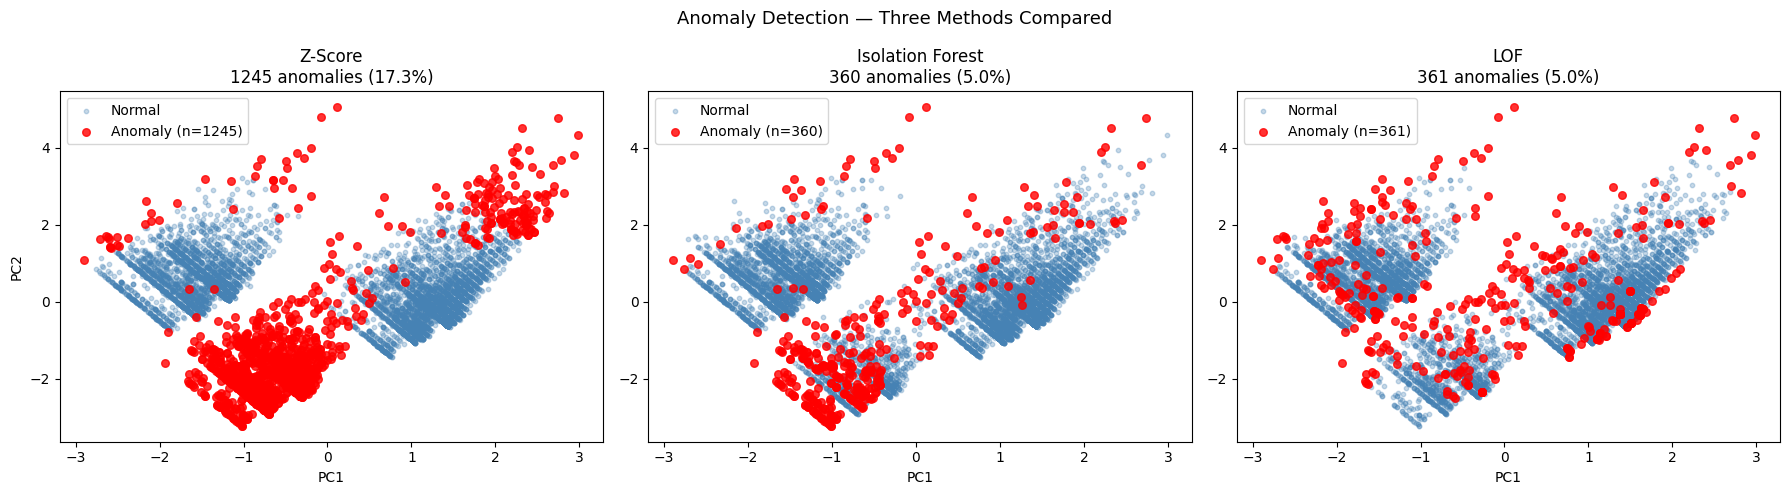

In [10]:
# Cell 10 - Local Outlier Factor (LOF)
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_predictions = lof.fit_predict(X_scaled)

# LOF also returns -1 for anomalies
lof_anomalies = lof_predictions == -1

print(f"Anomalies detected by LOF: {lof_anomalies.sum()}")
print(f"Anomaly rate: {lof_anomalies.mean():.1%}")

# Visualize all three methods together
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Z-Score
axes[0].scatter(X_pca[~z_anomalies, 0], X_pca[~z_anomalies, 1],
                c='steelblue', alpha=0.3, s=10, label='Normal')
axes[0].scatter(X_pca[z_anomalies, 0], X_pca[z_anomalies, 1],
                c='red', alpha=0.8, s=30, label=f'Anomaly (n={z_anomalies.sum()})')
axes[0].set_title(f'Z-Score\n{z_anomalies.sum()} anomalies ({z_anomalies.mean():.1%})')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()

# Isolation Forest
axes[1].scatter(X_pca[~iso_anomalies, 0], X_pca[~iso_anomalies, 1],
                c='steelblue', alpha=0.3, s=10, label='Normal')
axes[1].scatter(X_pca[iso_anomalies, 0], X_pca[iso_anomalies, 1],
                c='red', alpha=0.8, s=30, label=f'Anomaly (n={iso_anomalies.sum()})')
axes[1].set_title(f'Isolation Forest\n{iso_anomalies.sum()} anomalies ({iso_anomalies.mean():.1%})')
axes[1].set_xlabel('PC1')
axes[1].legend()

# LOF
axes[2].scatter(X_pca[~lof_anomalies, 0], X_pca[~lof_anomalies, 1],
                c='steelblue', alpha=0.3, s=10, label='Normal')
axes[2].scatter(X_pca[lof_anomalies, 0], X_pca[lof_anomalies, 1],
                c='red', alpha=0.8, s=30, label=f'Anomaly (n={lof_anomalies.sum()})')
axes[2].set_title(f'LOF\n{lof_anomalies.sum()} anomalies ({lof_anomalies.mean():.1%})')
axes[2].set_xlabel('PC1')
axes[2].legend()

plt.suptitle('Anomaly Detection — Three Methods Compared', fontsize=13)
plt.tight_layout()
plt.show()


## 🚨 Anomaly Detection — Three Methods Compared

### Results Summary:
| Method | Anomalies Found | Rate |
|---|---|---|
| Z-Score | 1,245 | 17.3% |
| Isolation Forest | 360 | 5.0% |
| LOF | 361 | 5.0% |

### Z-Score (left chart):
- Simplest method — flags points more than 3 standard deviations from mean
- Found 1,245 anomalies — way too many!
- Problem: our one-hot encoded race columns triggered many false positives
- Best for: simple numerical data without categorical variables

### Isolation Forest (middle chart):
- Uses random decision trees to isolate unusual points
- Anomalies are easier to isolate because they are few and different
- We set contamination=0.05 meaning "expect 5% anomalies"
- Anomalies concentrated at edges and boundaries — makes sense!
- Best for: large datasets with complex patterns

### LOF — Local Outlier Factor (right chart):
- Compares each point to its local neighbors
- A point is anomalous if its neighborhood is much less dense than its neighbors
- Very similar results to Isolation Forest (360 vs 361)
- Best for: datasets where anomalies are defined locally not globally

### What do these anomalies represent in criminal justice?
These are cases that don't fit normal patterns — for example:
- Very old person with extremely high prior convictions
- Very young person with unusual charge combinations
- Cases that might warrant closer human review

In [11]:
# Cell 11 - Consensus Anomalies
consensus = z_anomalies & iso_anomalies & lof_anomalies

print(f"Anomalies flagged by ALL three methods: {consensus.sum()}")
print(f"That's {consensus.mean():.1%} of all cases\n")

# What do these consensus anomalies look like?
anomaly_profiles = X[consensus].describe().round(2)
normal_profiles = X[~consensus].describe().round(2)

print("=== Consensus Anomaly Profile ===")
print(X[consensus][['age', 'priors_count']].describe().round(2))
print("\n=== Normal Cases Profile ===")
print(X[~consensus][['age', 'priors_count']].describe().round(2))

Anomalies flagged by ALL three methods: 104
That's 1.4% of all cases

=== Consensus Anomaly Profile ===
          age  priors_count
count  104.00        104.00
mean    49.24         13.48
std     16.06         10.82
min     20.00          0.00
25%     36.75          5.00
50%     50.50         10.50
75%     61.00         22.25
max     96.00         38.00

=== Normal Cases Profile ===
           age  priors_count
count  7110.00       7110.00
mean     34.61          3.33
std      11.69          4.58
min      18.00          0.00
25%      25.00          0.00
50%      31.00          2.00
75%      42.00          5.00
max      83.00         38.00


## 🎯 Consensus Anomalies — What All Three Methods Agree On

### Only 104 cases (1.4%) flagged by ALL three methods
These are the most confidently unusual cases in the dataset.

### Comparing Anomalies vs Normal Cases:

| | Anomalies | Normal Cases |
|---|---|---|
| Average Age | 49.2 years | 34.6 years |
| Average Priors | 13.48 | 3.33 |
| Max Priors | 38 | 38 |
| Min Age | 20 | 18 |

### What makes these cases anomalous?
The consensus anomalies are characterized by:
- **Much older** — average age 49 vs 35 for normal cases
- **Far more prior convictions** — average 13.5 vs 3.3 for normal cases
- These are **older repeat offenders** with extensive criminal histories

### Criminal Justice Interpretation:
These 104 cases represent individuals who are statistically 
unusual — not necessarily more dangerous, but different enough 
from the typical pattern that automated risk tools may not 
assess them accurately.

In practice, these cases would benefit most from:
- Individual human review
- Consideration of factors not in the dataset
- Extra caution about algorithmic decisions

### Key Takeaway:
Anomaly detection is not about labeling people as "dangerous" — 
it is about identifying cases where the model is least reliable 
and human judgment is most needed.